In [4]:
import pandas as pd

df = pd.read_csv("/content/AmesHousing.csv")
df.head()


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

#  Histograms of Numerical Features


In [6]:
def plot_histograms(df):

    plt.figure(figsize=(14,4))

    plt.subplot(1,3,1)
    df["SalePrice"].hist(bins=40)
    plt.title("SalePrice Distribution")

    plt.subplot(1,3,2)
    df["Gr Liv Area"].hist(bins=40)
    plt.title("Gr Liv Area Distribution")

    plt.subplot(1,3,3)
    df["Total Bsmt SF"].hist(bins=40)
    plt.title("Total Basement SF Distribution")

    plt.show()

    print("Insight: SalePrice shows a right-skewed distribution, while the size-related features look closer to a normal shape. This helps understand how spread out the values are.")


      
Insight: SalePrice shows a right-skewed distribution, while the size-related features look closer to a normal shape. This helps understand how spread out the values are.


# Boxplot of SalePrice by Overall Quality


In [7]:
def plot_boxplot(df):
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x="Overall Qual", y="SalePrice")
    plt.title("SalePrice by Overall Quality")
    plt.show()
    print("Insight: Higher Overall Quality is clearly associated with higher SalePrice. The median price increases steadily as quality improves.")


    

Insight: Higher Overall Quality is clearly associated with higher SalePrice. The median price increases steadily as quality improves.


#  Heatmap of Top Correlated Features






In [8]:
def plot_heatmap(df):

    numeric_clean = df.select_dtypes(include=['int64', 'float64'])
    top_corr = numeric_clean.corr()['SalePrice'].abs().sort_values(ascending=False).head(11).index

    plt.figure(figsize=(10,6))
    sns.heatmap(numeric_clean[top_corr].corr(), annot=True, cmap="coolwarm")
    plt.title("Top 10 Correlated Features with SalePrice")
    plt.show()
    print("Insight: Overall Quality and Gr Liv Area appear among the strongest predictors of SalePrice.")


    
**Insight: Overall Quality and Gr Liv Area appear among the strongest predictors of SalePrice.**

#  Scatter Plot of Gr Liv Area vs SalePrice


In [9]:
def plot_scatter(df):
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7,5))
    sns.scatterplot(
        data=df,
        x="Gr Liv Area",
        y="SalePrice",
        hue="Overall Qual",
        palette="viridis"
    )
    plt.title("Gr Liv Area vs SalePrice (Colored by Quality)")
    plt.show()
    print("Insight: Larger living areas tend to have higher prices, and homes with better quality ratings cluster toward the upper-right of the plot.")


    
Insight: Larger living areas tend to have higher prices, and homes with better quality ratings cluster toward the upper-right of the plot.


#  Grouped Summary by Overall Quality


In [10]:
def groupby_summary(df):
    summary = df.groupby("Overall Qual")["SalePrice"].mean().sort_values(ascending=False)
    print("Average SalePrice by Overall Quality:")
    print(summary)
    print("Insight: The highest quality categories show the highest average SalePrice, confirming that quality strongly influences home value.")

    return summary


    
Insight: The highest quality categories show the highest average SalePrice, confirming that quality strongly influences home value


In [11]:
def group_results(df):
     plot_histograms(df)
     plot_boxplot(df)
     plot_heatmap(df)
     plot_scatter(df)
     group_results = groupby_summary(df)
     return group_results


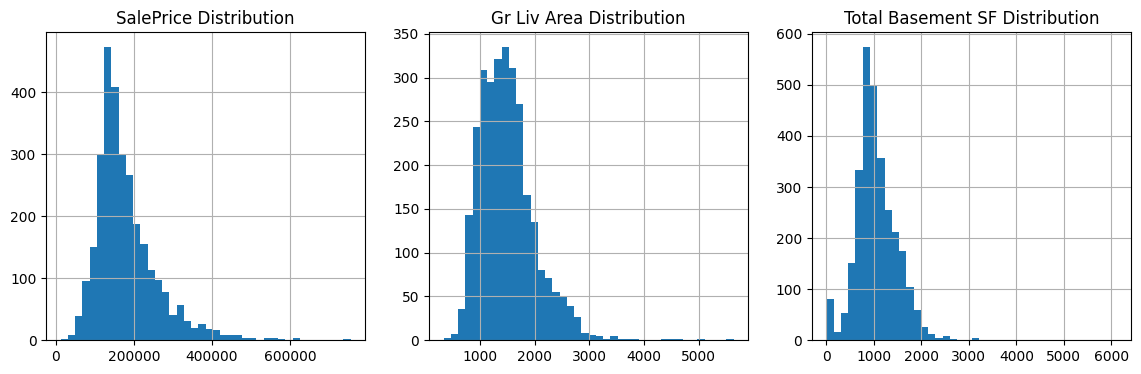

Insight: SalePrice shows a right-skewed distribution, while the size-related features look closer to a normal shape. This helps understand how spread out the values are.


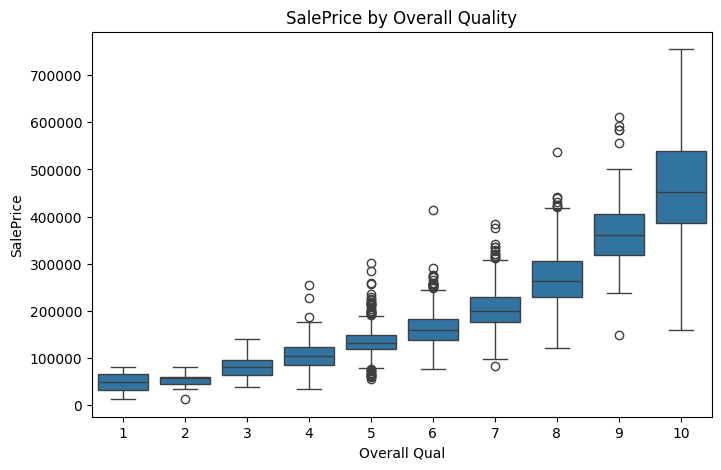

Insight: Higher Overall Quality is clearly associated with higher SalePrice. The median price increases steadily as quality improves.


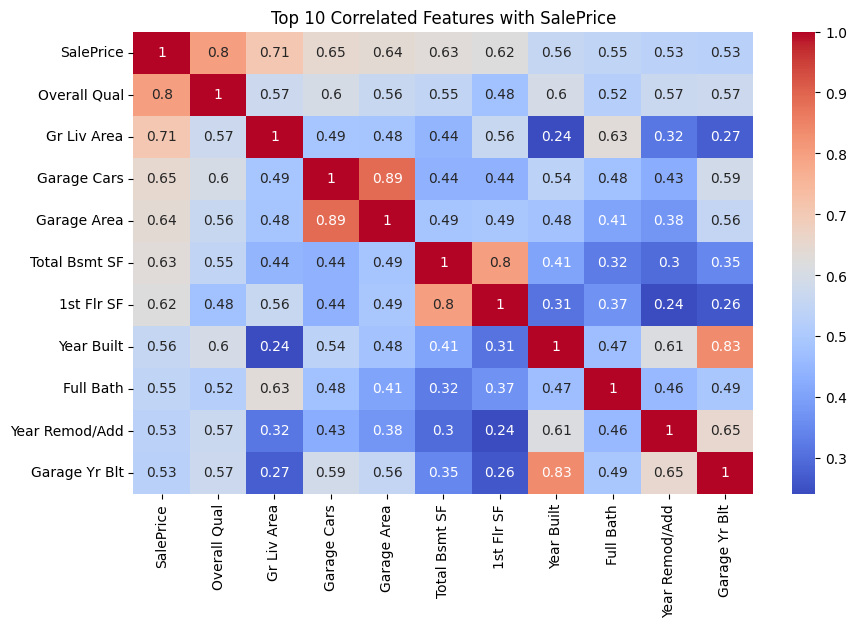

Insight: Overall Quality and Gr Liv Area appear among the strongest predictors of SalePrice.


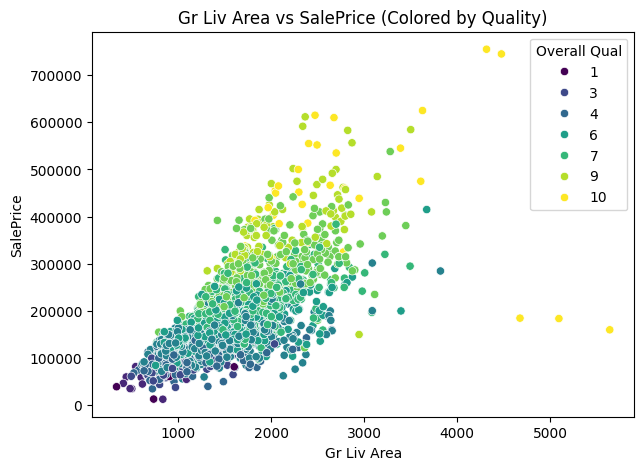

Insight: Larger living areas tend to have higher prices, and homes with better quality ratings cluster toward the upper-right of the plot.
Average SalePrice by Overall Quality:
Overall Qual
10    450217.322581
9     368336.766355
8     270913.594286
7     205025.760797
6     162130.318306
5     134752.516364
4     106485.097345
3      83185.975000
2      52325.307692
1      48725.000000
Name: SalePrice, dtype: float64
Insight: The highest quality categories show the highest average SalePrice, confirming that quality strongly influences home value.
Overall Qual
10    450217.322581
9     368336.766355
8     270913.594286
7     205025.760797
6     162130.318306
5     134752.516364
4     106485.097345
3      83185.975000
2      52325.307692
1      48725.000000
Name: SalePrice, dtype: float64


In [12]:
print(group_results(df))

In [13]:
"""
(plot_histograms)

Insight: SalePrice shows a right-skewed distribution, while the size-related features look closer to a normal shape. This helps understand how spread out the values are.
This skewness in SalePrice suggests that most homes are priced lower, with a few very expensive properties pulling the mean to the right.
Understanding the distribution shapes is important for selecting appropriate data transformations before modeling.
Additionally, features with near-normal distributions might perform well with linear models without heavy preprocessing.



(plot_boxplot)


Insight: Higher Overall Quality is clearly associated with higher SalePrice. The median price increases steadily as quality improves.
This indicates that homes with better construction, materials, and finishes tend to command higher market values.
Understanding this relationship can help in feature selection for predictive models, as Overall Quality is a strong predictor of SalePrice.
Additionally, it highlights the importance of investing in home quality improvements to increase resale value.

(plot_heatmap)

Insight: Overall Quality and Gr Liv Area appear among the strongest predictors of SalePrice.
This suggests that both the quality of the home and its above-ground living area have a major impact on its market value.
Homes with larger living spaces and higher overall quality tend to sell for significantly higher prices.
These features should be prioritized in predictive modeling, as they provide substantial explanatory power for SalePrice variations.

(plot_scatter)

Insight: Larger living areas tend to have higher prices, and homes with better quality ratings cluster toward the upper-right of the plot.
This indicates a positive correlation between home size, quality, and SalePrice.
It suggests that buyers are willing to pay more for spacious homes with superior finishes.
Such patterns can guide feature selection and engineering in predictive models to improve accuracy.

(groupby_summary)

Insight: The highest quality categories show the highest average SalePrice, confirming that quality strongly influences home value.
Homes in these top quality categories not only sell for more but also tend to appreciate faster over time.
This emphasizes that investing in construction quality and finishes can significantly increase a property's market value.
Predictive models should prioritize Overall Quality to capture its strong effect on SalePrice.

"""


"\n(plot_histograms)\n\nInsight: SalePrice shows a right-skewed distribution, while the size-related features look closer to a normal shape. This helps understand how spread out the values are.\nThis skewness in SalePrice suggests that most homes are priced lower, with a few very expensive properties pulling the mean to the right.\nUnderstanding the distribution shapes is important for selecting appropriate data transformations before modeling.\nAdditionally, features with near-normal distributions might perform well with linear models without heavy preprocessing.\n\n\n\n(plot_boxplot)\n\n\nInsight: Higher Overall Quality is clearly associated with higher SalePrice. The median price increases steadily as quality improves.\nThis indicates that homes with better construction, materials, and finishes tend to command higher market values.\nUnderstanding this relationship can help in feature selection for predictive models, as Overall Quality is a strong predictor of SalePrice.\nAdditionall